# Decision Tree Regressor Vs Random Forest Regressor

In [1]:
# Decision Tree Regressor
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
df = load_diabetes(as_frame=True).frame

In [3]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
df.shape

(442, 11)

In [5]:
X = df.drop("target",axis=1)
y = df["target"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=32)

In [7]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=7,min_samples_leaf=20)
model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [8]:
from sklearn.metrics import r2_score,mean_squared_error
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE train:",mean_squared_error(y_train,y_pred_train))
print("MSE test:",mean_squared_error(y_test,y_pred_test))

print("r2_square train:",r2_score(y_train,y_pred_train))
print("r2_square test:",r2_score(y_test,y_pred_test))

MSE train: 2847.7344700596286
MSE test: 3062.4688469298994
r2_square train: 0.5354615828971854
r2_square test: 0.43652895676640047


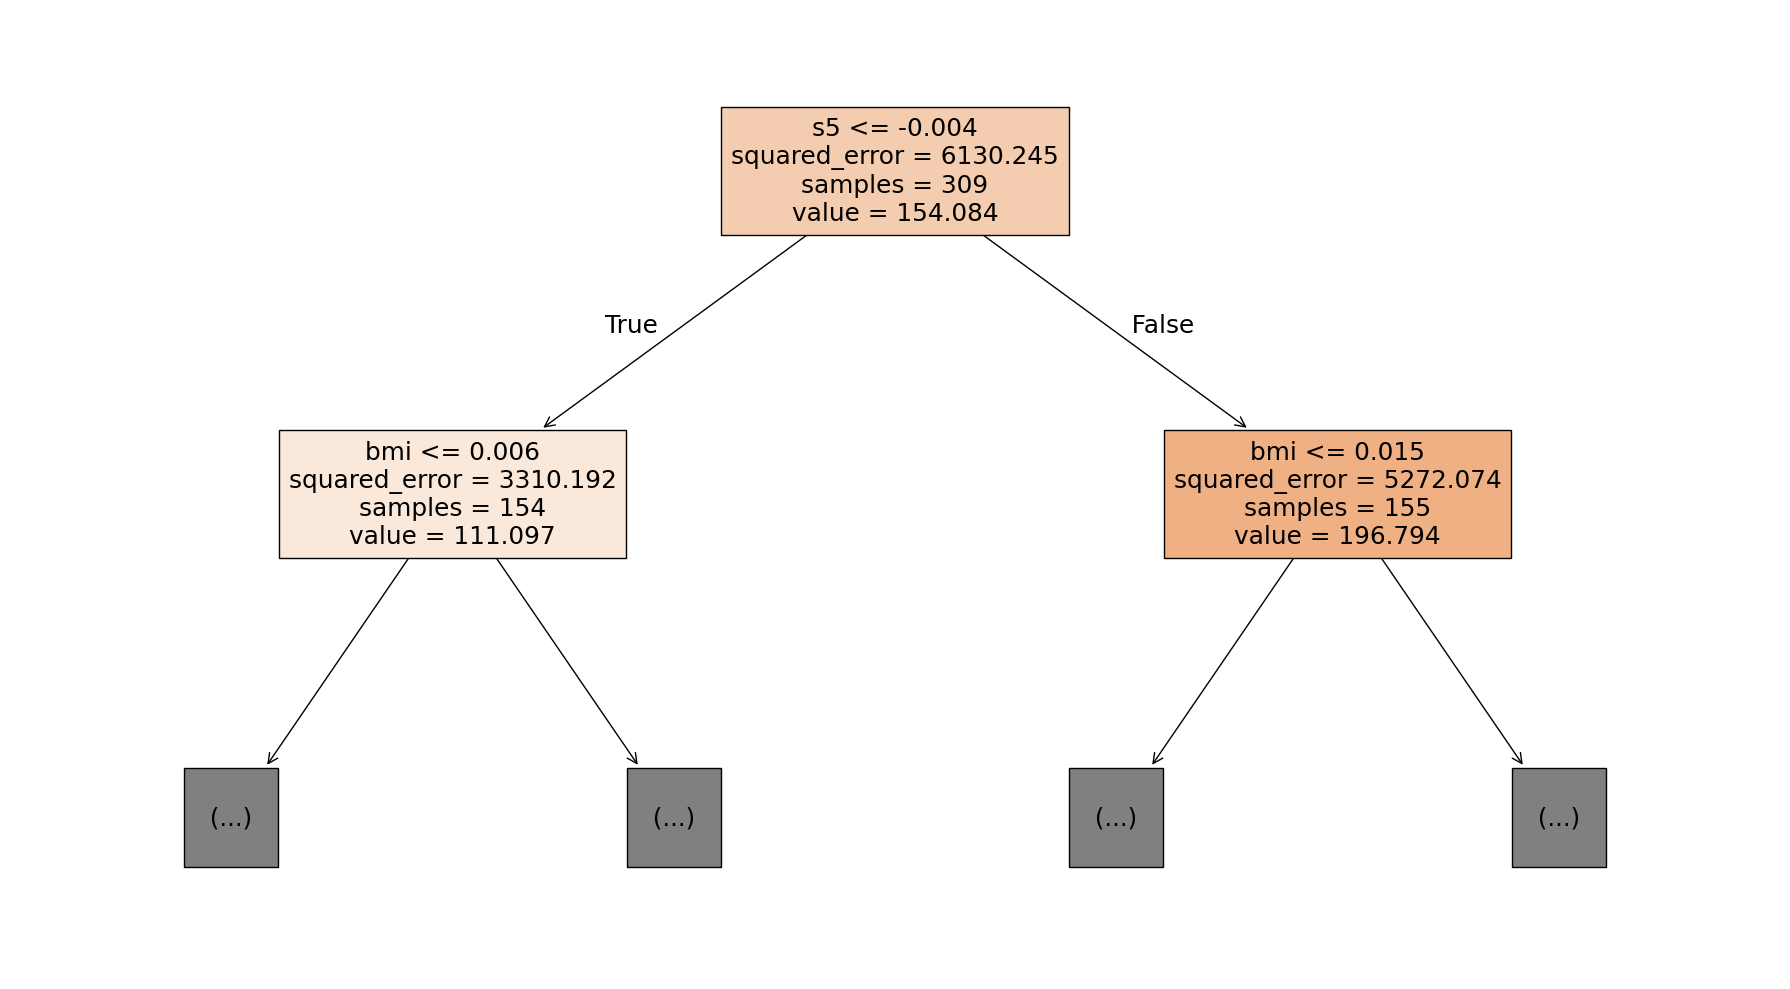

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    max_depth=1
)
plt.tight_layout()

# Random Forest Regressor

In [19]:
from sklearn.ensemble import RandomForestRegressor
# Import regression metrics instead of accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=7,            # Restricted depth to prevent memorization
    min_samples_leaf=15,    # Each leaf must have at least 15 samples
    max_features='sqrt',    # Only look at a subset of features for each split
    random_state=42
)
model.fit(X_train,y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Use R-squared (1.0 is a perfect fit)
print("Training R2 Score: ", r2_score(y_train, y_pred_train))
print("Testing R2 Score: ", r2_score(y_test, y_pred_test))

# Or use Mean Absolute Error (lower is better)
print("Training MAE: ", mean_absolute_error(y_train, y_pred_train))

Training R2 Score:  0.5538474389220929
Testing R2 Score:  0.4674693017974074
Training MAE:  43.87669881060371
